# Análise Profunda: Master Dataset
Este notebook foca-se na análise detalhada do ficheiro `master_dataset.csv`, cruzando os dados financeiros, de urgências, internamentos, cirurgias e consultas para descobrir padrões e correlações.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
current_dir = os.getcwd()
pasta_raiz = os.path.dirname(current_dir) if os.path.basename(current_dir) == 'notebooks' else current_dir
file_path = os.path.join(pasta_raiz, 'data', 'processed', 'master_dataset.csv')

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Master Dataset loaded! Dimension: {df.shape[0]} rows and {df.shape[1]} columns.")
else:
    print("Error: Master Dataset not found at the expected path.")

Master Dataset loaded! Dimension: 9147 rows and 45 columns.


In [31]:
df.info()
display(df.head())
display(df.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 6379 entries, 0 to 6378
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   regiao                                     6379 non-null   str    
 1   instituicao                                6379 non-null   str    
 2   ano                                        6379 non-null   int64  
 3   mes                                        6379 non-null   int64  
 4   ebitda                                     6379 non-null   float64
 5   gastos_operacionais                        6379 non-null   float64
 6   rendimentos_operacionais                   6379 non-null   float64
 7   resultado_liquido                          6379 non-null   float64
 8   resultados_operacionais                    6379 non-null   float64
 9   urgencias_geral                            6379 non-null   float64
 10  total_urgencias                    

,regiao,instituicao,ano,mes,ebitda,gastos_operacionais,rendimentos_operacionais,resultado_liquido,resultados_operacionais,urgencias_geral,...,no_intervencoes_cirurgicas_programadas,no_intervencoes_cirurgicas_convencionais,no_intervencoes_cirurgicas_de_ambulatorio,no_intervencoes_cirurgicas_urgentes,no_de_consultas_medicas_total,no_de_primeiras_consultas,no_de_consultas_subsequentes,divida_total_fornecedores_externos,divida_vencida_fornecedores_externos,pagamentos_em_atraso
0,Alentejo,Administração Regional de Saúde do Alentejo,2016,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19592349.91,11677606.83,9915.40
1,Alentejo,Administração Regional de Saúde do Alentejo,2016,2,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20331314.62,13080621.65,7809.39
2,Alentejo,Administração Regional de Saúde do Alentejo,2016,3,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21521352.96,14185670.92,31374.31
3,Alentejo,Administração Regional de Saúde do Alentejo,2016,4,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21633079.50,14100789.03,5527543.17
4,Alentejo,Administração Regional de Saúde do Alentejo,2016,5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16276366.15,8400615.48,14176.76


,regiao,instituicao,ano,mes,ebitda,gastos_operacionais,rendimentos_operacionais,resultado_liquido,resultados_operacionais,urgencias_geral,...,no_intervencoes_cirurgicas_programadas,no_intervencoes_cirurgicas_convencionais,no_intervencoes_cirurgicas_de_ambulatorio,no_intervencoes_cirurgicas_urgentes,no_de_consultas_medicas_total,no_de_primeiras_consultas,no_de_consultas_subsequentes,divida_total_fornecedores_externos,divida_vencida_fornecedores_externos,pagamentos_em_atraso
count,6379,6379,6379.000000,6379.000000,6.379000e+03,6.379000e+03,6.379000e+03,6.379000e+03,6.379000e+03,6379.000000,...,6379.000000,6379.000000,6379.000000,6379.000000,6.379000e+03,6379.000000,6379.000000,6.379000e+03,6.379000e+03,6.379000e+03
unique,6,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Norte,Unidade Local de Saúde da Póvoa de Varzim/Vila...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2117,121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2020.475780,6.530020,-9.230004e+06,8.211310e+07,7.129374e+07,-1.088365e+07,-1.093654e+07,44230.412447,...,6546.256467,2107.606835,4438.649632,993.508073,1.302153e+05,36918.599153,93296.682709,3.461848e+07,1.991679e+07,9.391730e+06
std,NaN,NaN,2.867324,3.459414,1.588238e+07,1.133468e+08,9.831157e+07,1.768783e+07,1.771305e+07,44521.488639,...,7944.238278,2668.310304,5425.155114,1232.315486,1.558520e+05,42315.284692,114201.128528,4.258231e+07,2.872014e+07,1.857341e+07
min,NaN,NaN,2016.000000,1.000000,-1.688819e+08,0.000000e+00,-6.411547e+06,-1.893682e+08,-1.886743e+08,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,-1.295877e+07,-3.002279e+07,-7.523691e+06
25%,NaN,NaN,2018.000000,4.000000,-1.239414e+07,5.735644e+06,5.298294e+06,-1.465668e+07,-1.475110e+07,4082.000000,...,1076.000000,335.000000,665.500000,117.500000,2.467350e+04,7064.500000,17093.500000,6.905233e+06,1.748961e+06,3.844950e+03
50%,NaN,NaN,2020.000000,7.000000,-3.621802e+06,4.524140e+07,3.869517e+07,-4.752628e+06,-4.834430e+06,34338.000000,...,4023.000000,1252.000000,2603.000000,603.000000,8.044400e+04,24080.000000,55303.000000,2.100892e+07,1.121476e+07,2.627477e+06
75%,NaN,NaN,2023.000000,10.000000,0.000000e+00,1.064922e+08,9.307668e+07,0.000000e+00,0.000000e+00,69962.500000,...,8820.000000,2734.500000,6139.000000,1395.500000,1.771805e+05,50875.000000,126814.000000,4.308167e+07,2.473201e+07,1.069201e+07


## Columns and Institutions Analysis
Verification of the number of unique institutions and their statistics.

In [4]:
if 'instituicao' in df.columns:
    num_institutions = df['instituicao'].nunique()
    print(f"There are {num_institutions} different institutions in the dataset.\n")
    print("All institutions and their record counts:")
    with pd.option_context('display.max_rows', None):
        display(df['instituicao'].value_counts().to_frame(name='Record Count'))
else:
    print("Column 'instituicao' not found in the dataset.")

There are 67 different institutions in the dataset.

All institutions and their record counts:


,Record Count
instituicao,
"Administração Central do Sistema de Saúde, I.P.",240
"Infarmed - Autoridade Nacional do Medicamento e Produtos de Saúde, I.P.",240
Instituto Nacional de Emergência Médica,240
"Instituto Nacional de Saúde Doutor Ricardo Jorge, I.P.",240
"Instituto Português do Sangue e da Transplantação, I.P.",240
"Instituto para os Comportamentos Aditivos e as Dependências, I. P.",240
"Serviços Partilhados do Ministério da Saúde, E.P.E.",240
Secretaria-Geral do Ministério da Saúde,239
Ação Governativa,231


## 1. Evolução Temporal Anual
Vamos agregar os dados por ano para ver a evolução a nível nacional da produtividade hospitalar.

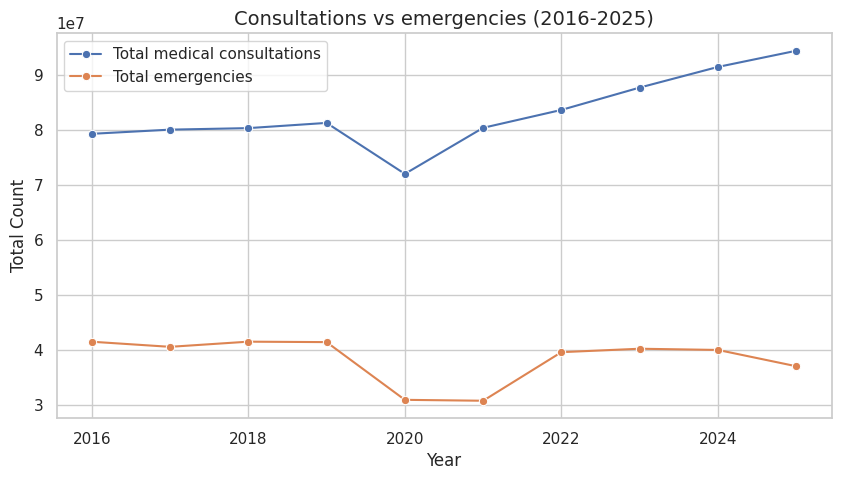

In [8]:
anual_evolution = df.groupby('ano').sum(numeric_only=True).reset_index()

plt.figure(figsize=(10, 5))
if 'no_de_consultas_medicas_total' in anual_evolution.columns:
    sns.lineplot(data=anual_evolution, x='ano', y='no_de_consultas_medicas_total', marker='o', label='Total medical consultations')
if 'total_urgencias' in anual_evolution.columns:
    sns.lineplot(data=anual_evolution, x='ano', y='total_urgencias', marker='o', label='Total emergencies')

plt.title('Consultations vs emergencies (2016-2025)', fontsize=14)
plt.ylabel('Total Count')
plt.xlabel('Year')
plt.legend()
plt.show()